# Congressional Trade Exploratory Analysis
This notebook Takes a look at the Congressional Trade Dataset and performs exploratory analysis to understand the data.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


# Load Dataset
df = pd.read_csv('../data/trades_with_returns.csv')
print(f"Dataset shape: {df.shape}")
print(f"Trades with valid returns: {df['return_90d'].notna().sum()}")


Dataset shape: (9675, 41)
Trades with valid returns: 8689


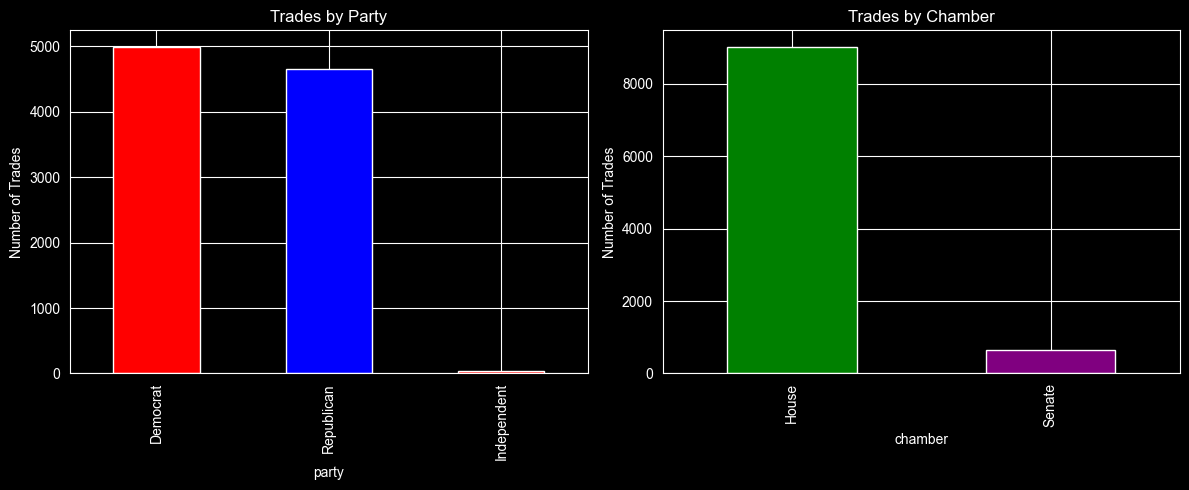

Republican: 4651 (48.1%)
Democrat: 4993 (51.6%)

Top 15 Most Active Traders:
politician_name
Ro Khanna           2647
Lisa McClain        1703
Michael McCaul       850
Gil Cisneros         662
Cleo Fields          434
Jefferson Shreve     250
Val Hoyle            245
Julie Johnson        242
Markwayne Mullin     209
Julia Letlow         206
John Boozman         174
David Taylor         151
Tim Moore            142
Scott Franklin       124
Kelly Morrison       124
Name: count, dtype: int64

Top Traders with Details:
                  num_trades       party chamber state   age  \
politician_name                                                
Ro Khanna               2647    Democrat   House    CA  50.0   
Lisa McClain            1703  Republican   House    MI  60.0   
Michael McCaul           850  Republican   House    TX  64.0   
Gil Cisneros             662    Democrat   House    CA  55.0   
Cleo Fields              434    Democrat   House    LA  64.0   
Jefferson Shreve         250  R

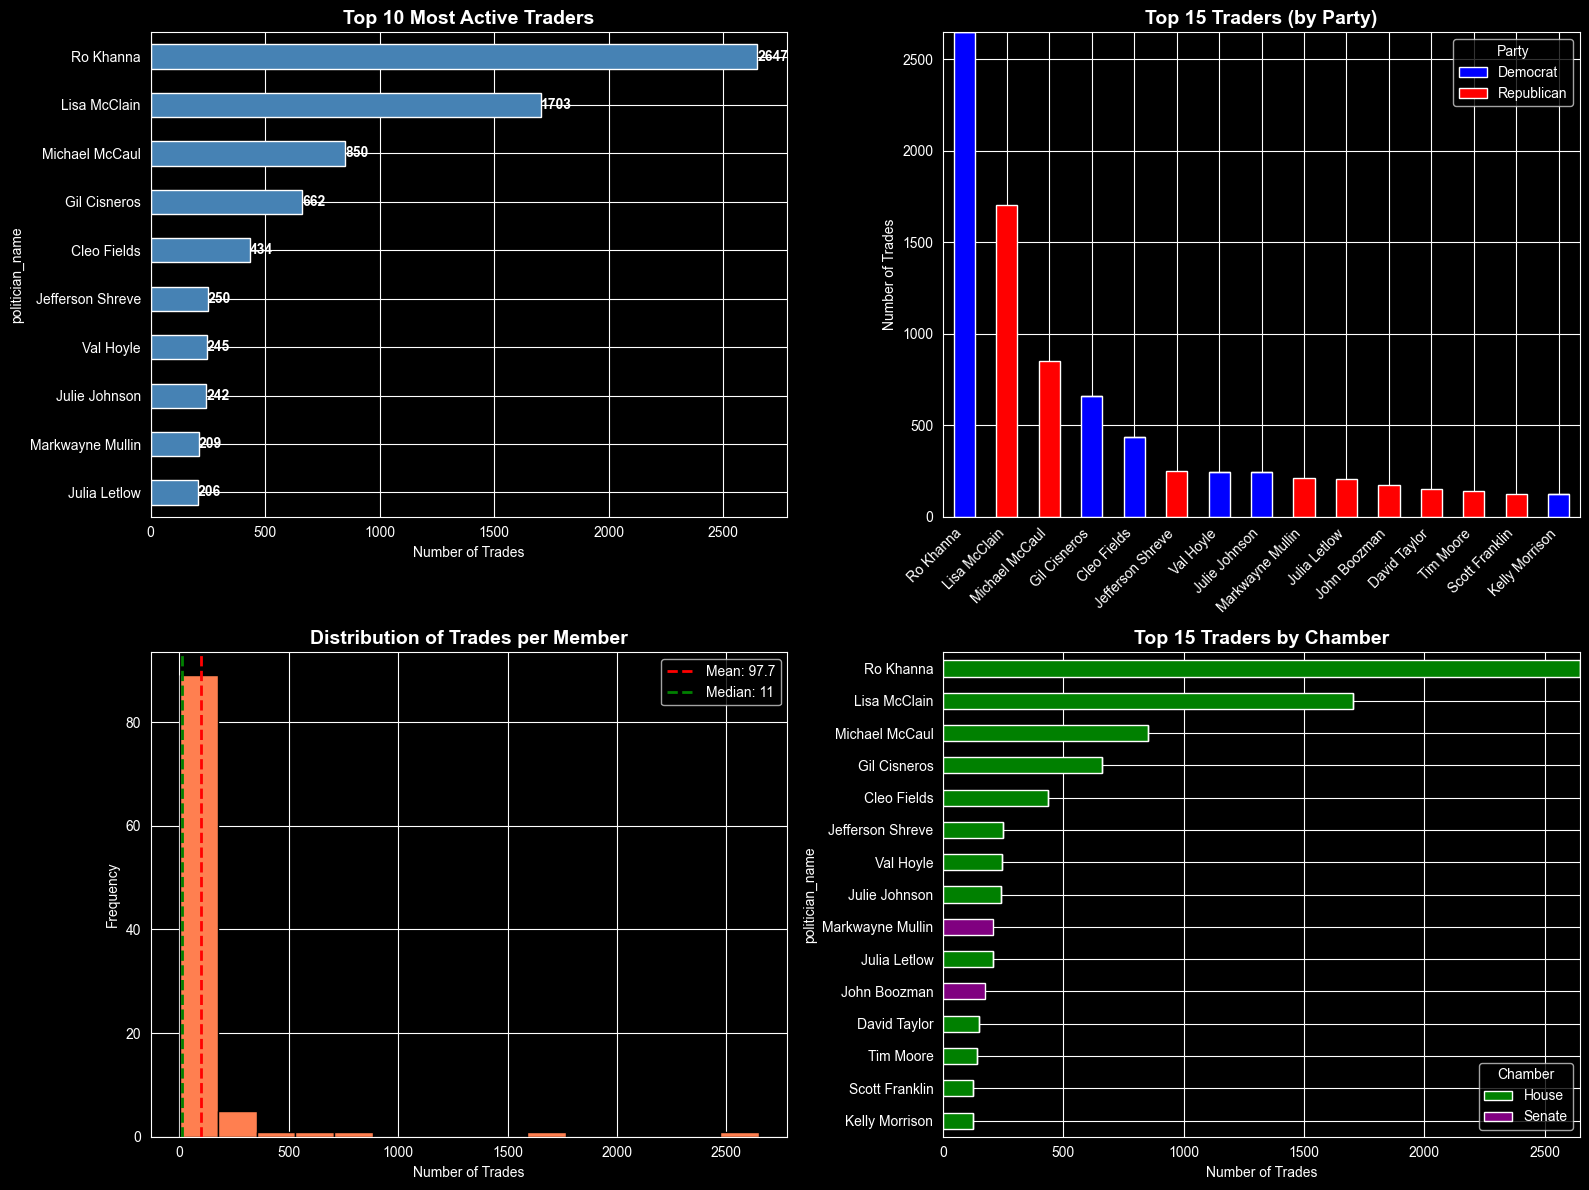

In [6]:

#Party and chamber distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Party
party_dist = df['party'].value_counts()
party_dist.plot(kind='bar', ax=axes[0], color=['red', 'blue'])
axes[0].set_title('Trades by Party')
axes[0].set_ylabel('Number of Trades')

# Chamber
chamber_dist = df['chamber'].value_counts()
chamber_dist.plot(kind='bar', ax=axes[1], color=['green', 'purple'])
axes[1].set_title('Trades by Chamber')
axes[1].set_ylabel('Number of Trades')

plt.tight_layout()
plt.show()

print(f"Republican: {party_dist.get('Republican', 0)} ({party_dist.get('Republican', 0)/len(df)*100:.1f}%)")
print(f"Democrat: {party_dist.get('Democrat', 0)} ({party_dist.get('Democrat', 0)/len(df)*100:.1f}%)")

# Most active traders
top_traders = df['politician_name'].value_counts().head(15)
print("\nTop 15 Most Active Traders:")
print(top_traders)

# Get additional details for top traders
print("\nTop Traders with Details:")
top_trader_details = df.groupby('politician_name').agg({
    'politician_name': 'count',
    'party': 'first',
    'chamber': 'first',
    'state': 'first',
    'age': 'first',
    'committee_power_score': 'first'
}).rename(columns={'politician_name': 'num_trades'})
top_trader_details = top_trader_details.sort_values('num_trades', ascending=False).head(15)
print(top_trader_details)

#visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#Top 10 traders - horizontal bar
top_traders.head(10).plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Top 10 Most Active Traders', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Number of Trades')
axes[0,0].invert_yaxis()
for i, v in enumerate(top_traders.head(10).values):
    axes[0,0].text(v + 0.1, i, str(v), va='center', fontweight='bold')
#Top traders by party
top_15_names = top_traders.head(15).index
top_15_df = df[df['politician_name'].isin(top_15_names)]
party_counts = top_15_df.groupby(['politician_name', 'party']).size().unstack(fill_value=0)
party_counts = party_counts.loc[top_traders.head(15).index]  # Maintain order
party_counts.plot(kind='bar', stacked=True, ax=axes[0,1], color=['blue', 'red'])
axes[0,1].set_title('Top 15 Traders (by Party)', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Number of Trades')
axes[0,1].set_xlabel('')
axes[0,1].legend(title='Party')
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=45, ha='right')

# Trades per member distribution
trades_per_member = df.groupby('politician_name').size()
axes[1,0].hist(trades_per_member.values, bins=15, edgecolor='black', color='coral')
axes[1,0].axvline(trades_per_member.mean(), color='red', linestyle='--',
                  linewidth=2, label=f'Mean: {trades_per_member.mean():.1f}')
axes[1,0].axvline(trades_per_member.median(), color='green', linestyle='--',
                  linewidth=2, label=f'Median: {trades_per_member.median():.0f}')
axes[1,0].set_title('Distribution of Trades per Member', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Number of Trades')
axes[1,0].set_ylabel('Frequency')
axes[1,0].legend()

# Top traders by chamber
chamber_counts = top_15_df.groupby(['politician_name', 'chamber']).size().unstack(fill_value=0)
chamber_counts = chamber_counts.loc[top_traders.head(15).index]
chamber_counts.plot(kind='barh', stacked=True, ax=axes[1,1], color=['green', 'purple'])
axes[1,1].set_title('Top 15 Traders by Chamber', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Number of Trades')
axes[1,1].legend(title='Chamber')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.show()


Top 15 Most Traded Stocks:
ticker
GOOGL    275
NVDA     247
MSFT     143
B        139
AAPL     135
VIG      116
META     107
AMZN     102
AVGO     100
JPM       87
UNH       87
TSM       71
ACN       71
JNJ       68
HD        63
Name: count, dtype: int64

Top Stocks with Company Names:
        num_trades                                issuer_name
ticker                                                       
GOOGL          275                               Alphabet Inc
NVDA           247                         NVIDIA Corporation
MSFT           143                             Microsoft Corp
B              139                     Berkshire Hathaway Inc
AAPL           135                                  Apple Inc
VIG            116         Vanguard Dividend Appreciation ETF
META           107                         Meta Platforms Inc
AMZN           102                             Amazon.com Inc
AVGO           100                               Broadcom Inc
JPM             87            

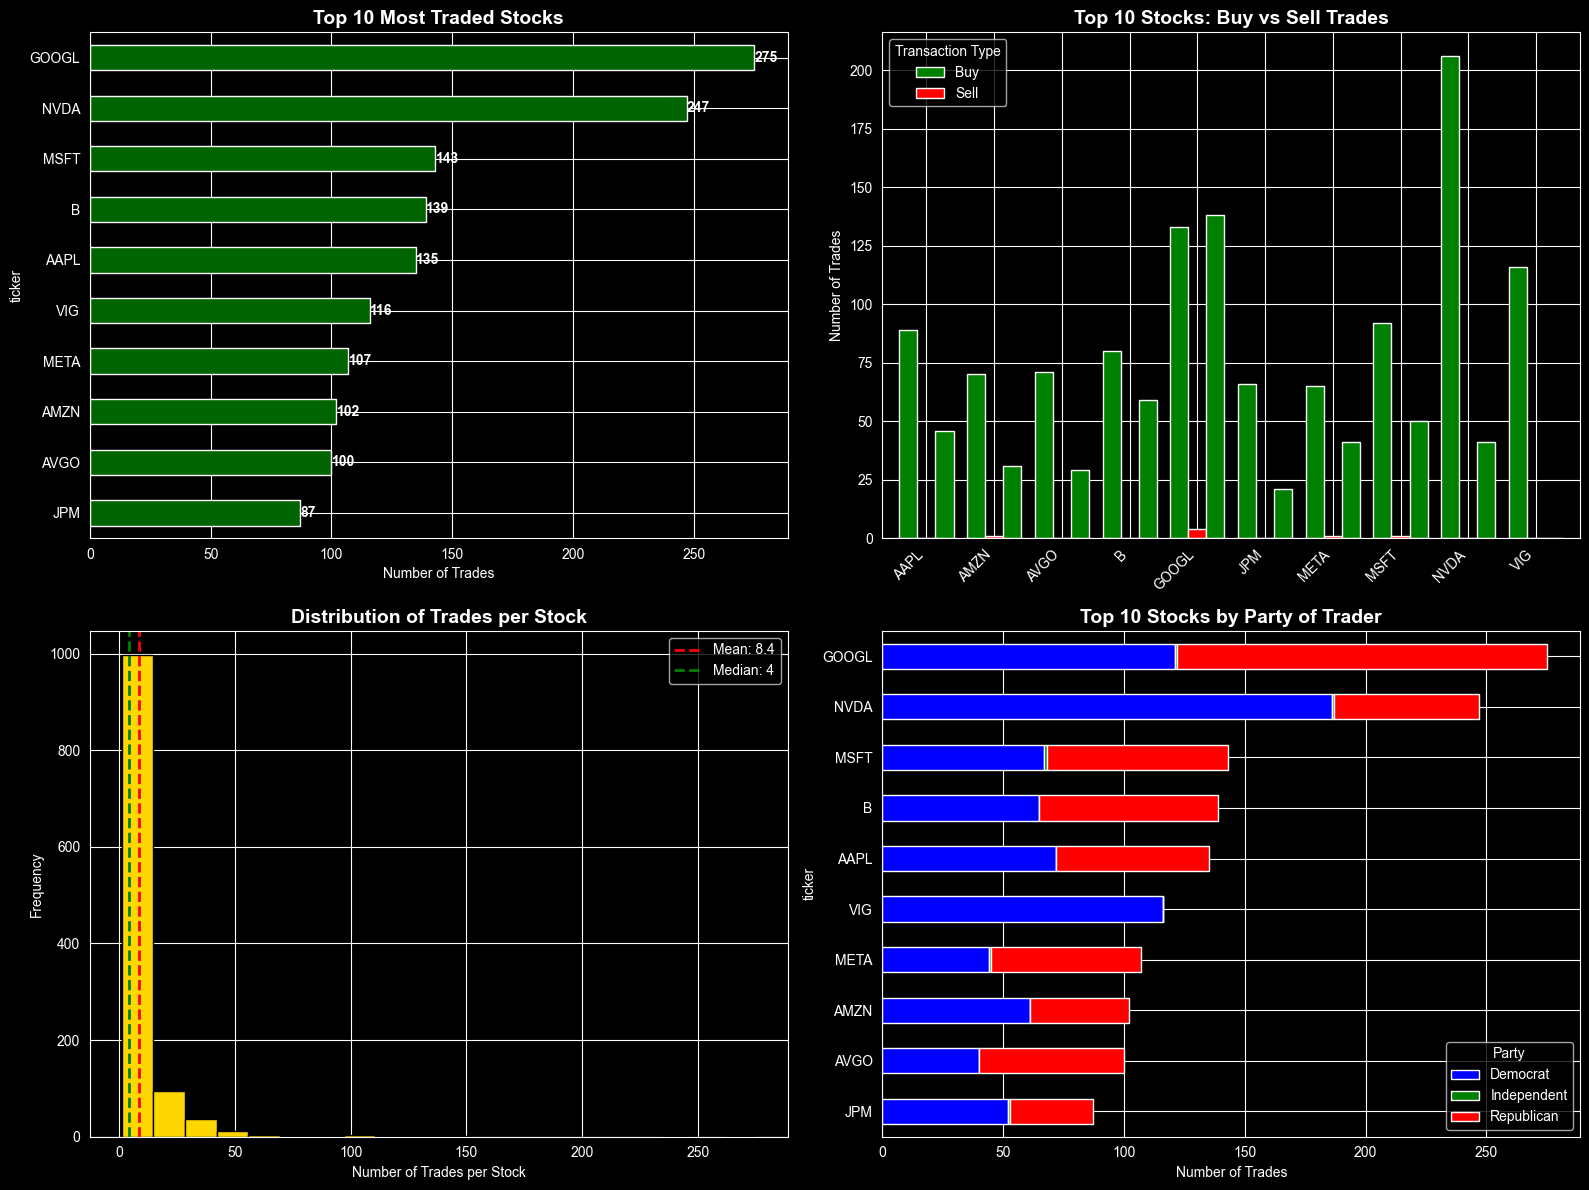

In [10]:
# Most traded stocks
top_stocks = df['ticker'].value_counts().head(15)
print("\nTop 15 Most Traded Stocks:")
print(top_stocks)

# Get stock names
print("\nTop Stocks with Company Names:")
top_stock_details = df[df['ticker'].isin(top_stocks.index)].groupby('ticker').agg({
    'ticker': 'count',
    'issuer_name': 'first'
}).rename(columns={'ticker': 'num_trades'})
top_stock_details = top_stock_details.loc[top_stocks.index]  # Maintain order
print(top_stock_details)

# Transaction type breakdown for top stocks
print("\nTransaction Types for Top 10 Stocks:")
top_10_stocks = top_stocks.head(10).index
stock_trans_breakdown = df[df['ticker'].isin(top_10_stocks)].groupby(['ticker', 'transaction_type']).size().unstack(fill_value=0)
print(stock_trans_breakdown)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top 10 stocks - horizontal bar
top_stocks.head(10).plot(kind='barh', ax=axes[0,0], color='darkgreen')
axes[0,0].set_title('Top 10 Most Traded Stocks', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Number of Trades')
axes[0,0].invert_yaxis()
for i, v in enumerate(top_stocks.head(10).values):
    axes[0,0].text(v + 0.1, i, str(v), va='center', fontweight='bold')

# Buy vs Sell for top stocks
if 'buy' in stock_trans_breakdown.columns and 'sell' in stock_trans_breakdown.columns:
    stock_trans_breakdown.head(10).plot(kind='bar', ax=axes[0,1], color=['green', 'red'], width=0.8)
    axes[0,1].set_title('Top 10 Stocks: Buy vs Sell Trades', fontsize=14, fontweight='bold')
    axes[0,1].set_ylabel('Number of Trades')
    axes[0,1].set_xlabel('')
    axes[0,1].legend(title='Transaction Type', labels=['Buy', 'Sell'])
    axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=45, ha='right')

# Trades per stock distribution
trades_per_stock = df.groupby('ticker').size()
axes[1,0].hist(trades_per_stock.values, bins=20, edgecolor='black', color='gold')
axes[1,0].axvline(trades_per_stock.mean(), color='red', linestyle='--',
                  linewidth=2, label=f'Mean: {trades_per_stock.mean():.1f}')
axes[1,0].axvline(trades_per_stock.median(), color='green', linestyle='--',
                  linewidth=2, label=f'Median: {trades_per_stock.median():.0f}')
axes[1,0].set_title('Distribution of Trades per Stock', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Number of Trades per Stock')
axes[1,0].set_ylabel('Frequency')
axes[1,0].legend()

# Top stocks by party
top_10_df = df[df['ticker'].isin(top_10_stocks)]
stock_party = top_10_df.groupby(['ticker', 'party']).size().unstack(fill_value=0)
stock_party = stock_party.loc[top_stocks.head(10).index]
stock_party.plot(kind='barh', stacked=True, ax=axes[1,1], color=['blue', 'green', 'red'])
axes[1,1].set_title('Top 10 Stocks by Party of Trader', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Number of Trades')
axes[1,1].legend(title='Party')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.show()

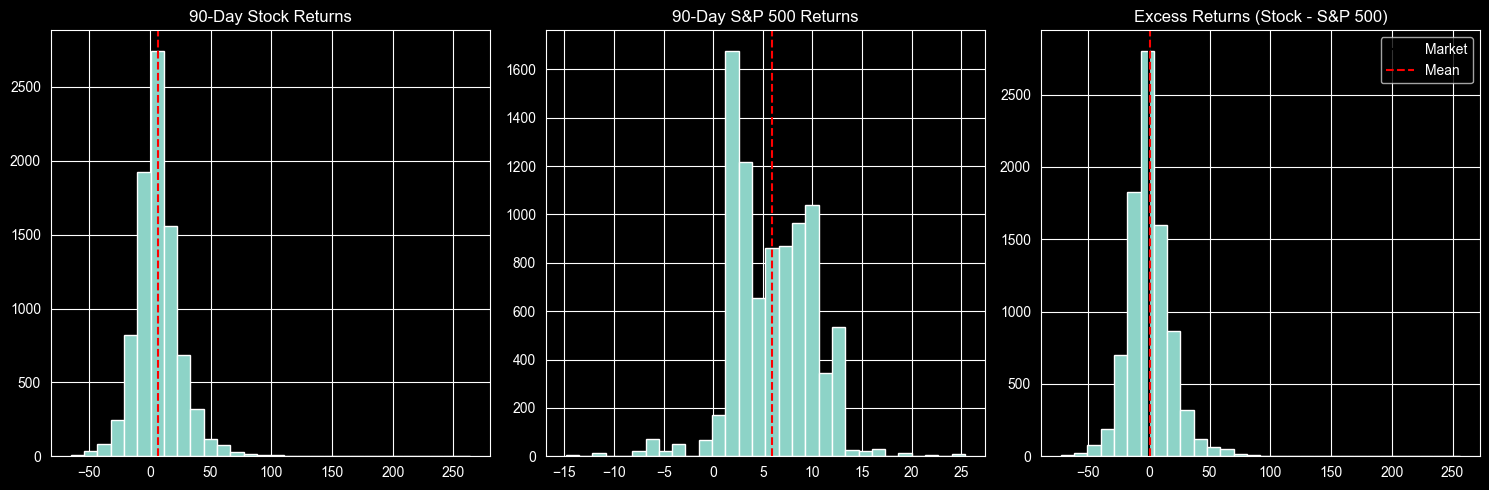

In [11]:
# Return Distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Stock returns
df['return_90d'].hist(bins=30, ax=axes[0])
axes[0].axvline(df['return_90d'].mean(), color='r', linestyle='--')
axes[0].set_title('90-Day Stock Returns')

# S&P 500 returns
df['sp500_return_90d'].hist(bins=30, ax=axes[1])
axes[1].axvline(df['sp500_return_90d'].mean(), color='r', linestyle='--')
axes[1].set_title('90-Day S&P 500 Returns')

# Excess returns
df['excess_return_90d'].hist(bins=30, ax=axes[2])
axes[2].axvline(0, color='black', linestyle='-', label='Market')
axes[2].axvline(df['excess_return_90d'].mean(), color='r', linestyle='--', label='Mean')
axes[2].set_title('Excess Returns (Stock - S&P 500)')
axes[2].legend()

plt.tight_layout()
plt.show()


In [12]:
# Do Congressional Trades Beat the Market?
print("="*60)
print("DO CONGRESSIONAL TRADES BEAT THE MARKET?")
print("="*60)
print(f"Mean stock return: {df['return_90d'].mean():.2f}%")
print(f"Mean S&P 500 return: {df['sp500_return_90d'].mean():.2f}%")
print(f"Mean excess return: {df['excess_return_90d'].mean():.2f}%")
print(f"% of trades outperforming: {(df['excess_return_90d'] > 0).mean()*100:.1f}%")

# Performance by Features

# party
party_perf = df.groupby('party')['excess_return_90d'].agg(['mean', 'count'])
print("\nPerformance by Party:")
print(party_perf)

# chamber
chamber_perf = df.groupby('chamber')['excess_return_90d'].agg(['mean', 'count'])
print("\nPerformance by Chamber:")
print(chamber_perf)

# filing delay buckets
df['filing_bucket'] = pd.cut(df['filed_after_days'], bins=[0, 15, 30, 45])
delay_perf = df.groupby('filing_bucket')['excess_return_90d'].agg(['mean', 'count'])
print("\nPerformance by Filing Delay:")
print(delay_perf)

# Top Performers
top_performers = df.nlargest(10, 'excess_return_90d')[
    ['politician_name', 'ticker', 'traded_date', 'excess_return_90d',
     'committee_power_score', 'filed_after_days']
]
print("\nTop 10 Trades by Excess Return:")
print(top_performers)



DO CONGRESSIONAL TRADES BEAT THE MARKET?
Mean stock return: 6.55%
Mean S&P 500 return: 5.90%
Mean excess return: 0.65%
% of trades outperforming: 41.3%

Performance by Party:
                 mean  count
party                       
Democrat     0.187488   4470
Independent  1.764532     27
Republican   1.132730   4192

Performance by Chamber:
             mean  count
chamber                 
House    0.471820   8263
Senate   4.073885    426

Performance by Filing Delay:
                   mean  count
filing_bucket                 
(0, 15]        1.228406   1207
(15, 30]       2.094911   3636
(30, 45]      -1.721947   2369

Top 10 Trades by Excess Return:
               politician_name ticker traded_date  excess_return_90d  \
7597               Cleo Fields   IREN  2025-07-09         256.161549   
4081              Lisa McClain   RGTI  2025-07-16         232.505565   
7707               Cleo Fields   OPEN  2025-07-20         212.063319   
2838              Lisa McClain   SNDK  2025-10-30

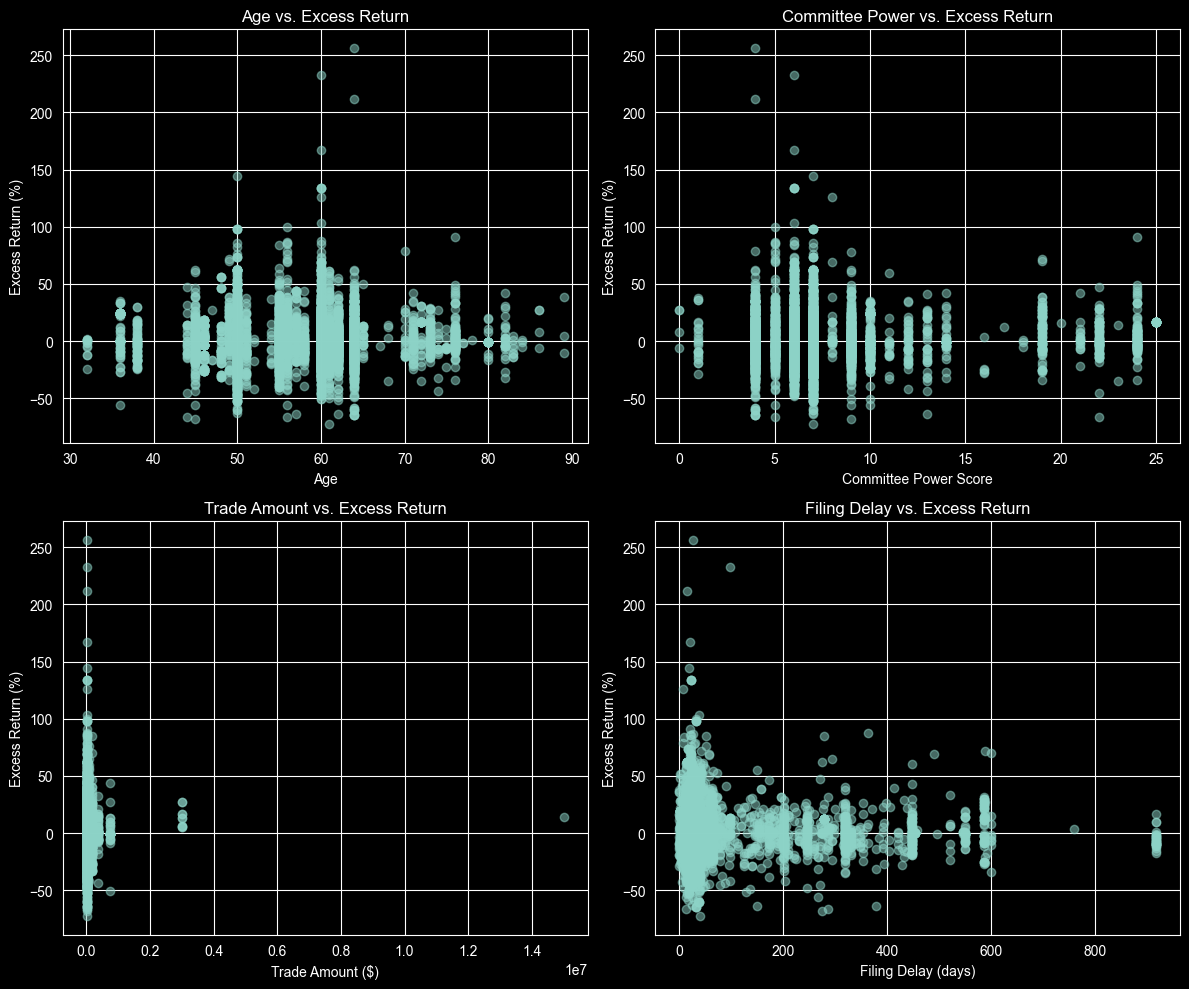


Target Variable (Outperformed by >5%):
outperformed_90d
0.0    5755
1.0    2934
Name: count, dtype: int64
Class balance: 33.8% outperformed


In [13]:
# Feature Relationships
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Age vs excess return
axes[0,0].scatter(df['age'], df['excess_return_90d'], alpha=0.5)
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Excess Return (%)')
axes[0,0].set_title('Age vs. Excess Return')

# Committee power vs excess return
axes[0,1].scatter(df['committee_power_score'], df['excess_return_90d'], alpha=0.5)
axes[0,1].set_xlabel('Committee Power Score')
axes[0,1].set_ylabel('Excess Return (%)')
axes[0,1].set_title('Committee Power vs. Excess Return')

# Trade amount vs excess return
axes[1,0].scatter(df['trade_amount'], df['excess_return_90d'], alpha=0.5)
axes[1,0].set_xlabel('Trade Amount ($)')
axes[1,0].set_ylabel('Excess Return (%)')
axes[1,0].set_title('Trade Amount vs. Excess Return')

# Filing delay vs excess return
axes[1,1].scatter(df['filed_after_days'], df['excess_return_90d'], alpha=0.5)
axes[1,1].set_xlabel('Filing Delay (days)')
axes[1,1].set_ylabel('Excess Return (%)')
axes[1,1].set_title('Filing Delay vs. Excess Return')

plt.tight_layout()
plt.show()

# Target Variable Distribution
print("\nTarget Variable (Outperformed by >5%):")
print(df['outperformed_90d'].value_counts())
print(f"Class balance: {df['outperformed_90d'].mean()*100:.1f}% outperformed")